In [22]:
import numpy as np
import xgboost as xg
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import classification_report ,accuracy_score
import joblib
import pandas as pd

In [31]:
data = pd.read_csv('data.csv')
features = [
    'home_rolling_scored_5', 'home_rolling_conceded_5',
    'away_rolling_scored_5', 'away_rolling_conceded_5',
    'home_team_rank', 'away_team_rank', 
    'neutral' 
]
X = data[features]
y = data['target']


In [ ]:
#spliting the data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2 , random_state=42,shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


,home_rolling_scored_5,home_rolling_conceded_5,away_rolling_scored_5,away_rolling_conceded_5,home_team_rank,away_team_rank,neutral
0,2.0,1.0,3.0,0.0,119.0,99.0,0
1,4.0,1.0,3.0,1.0,137.0,94.0,0
2,1.5,0.0,1.0,0.5,99.0,119.0,0
3,0.0,0.0,2.0,0.0,56.0,61.0,0
4,0.0,0.0,0.0,2.0,79.0,145.0,1
...,...,...,...,...,...,...,...
2187,0.8,3.0,1.4,1.0,146.0,26.0,1
2188,1.2,0.6,0.6,1.0,63.0,77.0,1
2189,1.2,1.0,1.2,0.2,43.0,66.0,0
2190,0.2,1.2,0.0,1.8,136.0,172.0,0


In [33]:
#model logreg
model = LogisticRegression(max_iter=1000)
print('Training has started')
print('\n --------------------------------')
model.fit(X_train_scaled,y_train)
print('Training has ended')



Training has started

 --------------------------------
Training has ended


In [34]:
#test
predict = model.predict(X_test_scaled)
loss = accuracy_score(y_test , predict)
print(f'accuracy is = {loss:.2f}')

accuracy is = 0.61


In [35]:
#xgb
param_grid = {
    'n_estimators': [50,100, 200, 300],        
    'max_depth': [2,3, 5, 7],                
    'learning_rate': [0.01, 0.05, 0.1]       
}
xgb = xg.XGBClassifier(random_state=42)
Grid=GridSearchCV(estimator=xgb ,param_grid=param_grid ,cv=3 ,scoring='accuracy' ,verbose=1 ,n_jobs=-1)
Grid.fit(X_train,y_train)

gridp = Grid.best_estimator_.predict(X_test)
gridloss =  accuracy_score(y_test , gridp)
print(f'accuracy is = {gridloss:.2f}')
best_model = Grid.best_estimator_


Fitting 3 folds for each of 48 candidates, totalling 144 fits
accuracy is = 0.61


In [37]:
joblib.dump(best_model ,'Xgb_model.pkl')

['Xgb_model.pkl']

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

<Figure size 800x800 with 0 Axes>

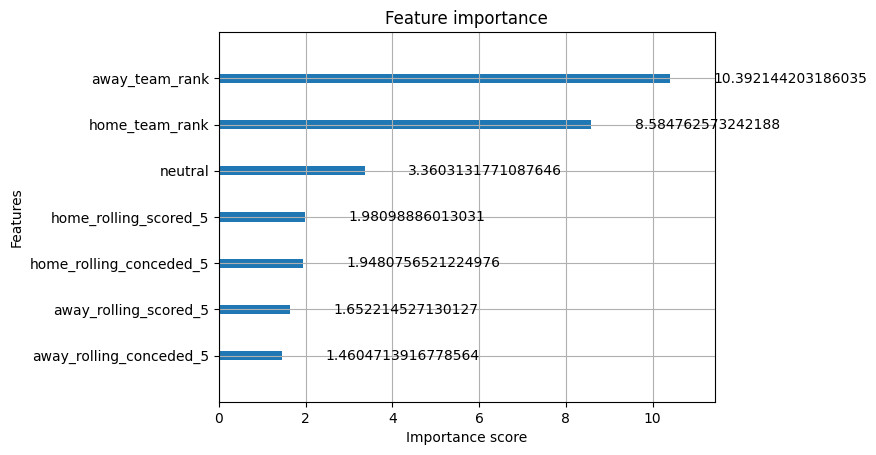

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
xg.plot_importance(best_model ,importance_type='gain')
